1. 하계 올림픽 데이터 로드
2. 개최국 + 개최연도 추출
3. 1970년 이후 개최국 필터
4. 국가명 통일
5. GDP 데이터 로드
6. 개최연도 ±5년 GDP 추출
7. GDP 성장률 계산
8. 시각화 (히트맵 + 평균 추이)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib


In [ ]:
df = pd.read_csv("olympic_games.csv")
df


,year,games_type,host_country,host_city,athletes,teams,competitions,country,gold,silver,bronze
0,2022,Winter,China,Beijing,2834,91,109,Australia,1,2,1
1,2022,Winter,China,Beijing,2834,91,109,Austria,7,7,4
2,2022,Winter,China,Beijing,2834,91,109,Belarus,0,2,0
3,2022,Winter,China,Beijing,2834,91,109,Belgium,1,0,1
4,2022,Winter,China,Beijing,2834,91,109,Canada,4,8,14
...,...,...,...,...,...,...,...,...,...,...,...
1776,1896,Summer,Greece,Athens,241,14,43,Hungary,2,1,3
1777,1896,Summer,Greece,Athens,241,14,43,Mixed team,1,0,1
1778,1896,Summer,Greece,Athens,241,14,43,Switzerland,1,2,0
1779,1896,Summer,Greece,Athens,241,14,43,United Kingdom,3,3,3


In [ ]:
# 하계 올림픽 데이터만 불러오기

df_summer = df[df['games_type'] == 'Summer'].copy()
df_summer

,year,games_type,host_country,host_city,athletes,teams,competitions,country,gold,silver,bronze
29,2020,Summer,Japan,Tokyo,11420,206,339,Argentina,0,1,2
30,2020,Summer,Japan,Tokyo,11420,206,339,Armenia,0,2,2
31,2020,Summer,Japan,Tokyo,11420,206,339,Australia,17,7,22
32,2020,Summer,Japan,Tokyo,11420,206,339,Austria,1,1,5
33,2020,Summer,Japan,Tokyo,11420,206,339,Azerbaijan,0,3,4
...,...,...,...,...,...,...,...,...,...,...,...
1776,1896,Summer,Greece,Athens,241,14,43,Hungary,2,1,3
1777,1896,Summer,Greece,Athens,241,14,43,Mixed team,1,0,1
1778,1896,Summer,Greece,Athens,241,14,43,Switzerland,1,2,0
1779,1896,Summer,Greece,Athens,241,14,43,United Kingdom,3,3,3


In [ ]:
# 개최국 + 개최연도 추출

host_year = (
    df_summer[['host_country', 'year']]
    .drop_duplicates()
    .rename(columns={'year': 'host_year'})
)

host_year


,host_country,host_year
29,Japan,2020
152,Brazil,2016
264,Great Britain,2012
376,China,2008
489,Greece,2004
587,Australia,2000
691,United States,1996
792,Spain,1992
876,Republic of Korea,1988
945,United States,1984


In [ ]:
# 1980년 이후 개최국만 남기기 -> GDP 데이터가 1960년 부터 있는데 이를 해결하기 위해

host_year = host_year[host_year['host_year'] >= 1984].copy()
host_year


,host_country,host_year
29,Japan,2020
152,Brazil,2016
264,Great Britain,2012
376,China,2008
489,Greece,2004
587,Australia,2000
691,United States,1996
792,Spain,1992
876,Republic of Korea,1988
945,United States,1984


In [ ]:
# 국가명 통일

country_map = {
    "United States": "United States",
    "Great Britain": "United Kingdom",
    "Republic of Korea": "Korea, Rep.",
    "Federal Republic of Germany": "Germany",
    "USSR": "Russian Federation"
}

# 예 : Great Britain"-> "United Kingdom
host_year['Country Name'] = host_year['host_country'].replace(country_map)
host_year = host_year.dropna(subset=['Country Name'])


host_year

,host_country,host_year,Country Name
29,Japan,2020,Japan
152,Brazil,2016,Brazil
264,Great Britain,2012,United Kingdom
376,China,2008,China
489,Greece,2004,Greece
587,Australia,2000,Australia
691,United States,1996,United States
792,Spain,1992,Spain
876,Republic of Korea,1988,"Korea, Rep."
945,United States,1984,United States


In [ ]:
# host_country에서 미국이 1984년과 1996년으로 나누는 과정

host_year = host_year.copy()

host_year.loc[
    (host_year['host_country'] == 'United States') &
    (host_year['host_year'] == 1984),
    'host_country'
] = 'United States (Los Angeles)'

host_year.loc[
    (host_year['host_country'] == 'United States') &
    (host_year['host_year'] == 1996),
    'host_country'
] = 'United States (Atlanta)'

host_year

,host_country,host_year,Country Name
29,Japan,2020,Japan
152,Brazil,2016,Brazil
264,Great Britain,2012,United Kingdom
376,China,2008,China
489,Greece,2004,Greece
587,Australia,2000,Australia
691,United States (Atlanta),1996,United States
792,Spain,1992,Spain
876,Republic of Korea,1988,"Korea, Rep."
945,United States (Los Angeles),1984,United States


In [ ]:
df_gdp = pd.read_csv('gdp.csv',skiprows=4)
df_gdp


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Unnamed: 69
0,Aruba,ABW,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2.983637e+09,3.092428e+09,3.276188e+09,3.346623e+09,2.471419e+09,2.880903e+09,3.324034e+09,3.834730e+09,4.265651e+09,NaN
1,Africa Eastern and Southern,AFE,GDP (current US$),NY.GDP.MKTP.CD,2.420569e+10,2.495889e+10,2.707323e+10,3.176914e+10,3.027955e+10,3.380618e+10,...,8.318681e+11,9.780765e+11,1.020956e+12,1.018715e+12,9.386076e+11,1.114145e+12,1.228968e+12,1.179359e+12,1.242694e+12,NaN
2,Afghanistan,AFG,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,1.811657e+10,1.875346e+10,1.805322e+10,1.879944e+10,1.995593e+10,1.426000e+10,1.449724e+10,1.715223e+10,NaN,NaN
3,Africa Western and Central,AFW,GDP (current US$),NY.GDP.MKTP.CD,1.190481e+10,1.270772e+10,1.363059e+10,1.446891e+10,1.580356e+10,1.692088e+10,...,7.000282e+11,6.940513e+11,7.778403e+11,1.026996e+12,9.637847e+11,1.026651e+12,1.063649e+12,9.382384e+11,7.363850e+11,NaN
4,Angola,AGO,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,5.987825e+10,8.437694e+10,8.951279e+10,8.073443e+10,5.885246e+10,7.955954e+10,1.312122e+11,1.071677e+11,1.009989e+11,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,Kosovo,XKX,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,6.682677e+09,7.180769e+09,7.878763e+09,7.899741e+09,7.717143e+09,9.413409e+09,9.354908e+09,1.046822e+10,1.119725e+10,NaN
262,"Yemen, Rep.",YEM,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,3.131783e+10,2.684223e+10,2.160616e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
263,South Africa,ZAF,GDP (current US$),NY.GDP.MKTP.CD,8.748597e+09,9.225996e+09,9.813996e+09,1.085420e+10,1.195600e+10,1.306899e+10,...,3.235855e+11,3.814488e+11,4.052607e+11,3.893300e+11,3.379747e+11,4.199863e+11,4.075960e+11,3.814407e+11,4.011450e+11,NaN
264,Zambia,ZMB,GDP (current US$),NY.GDP.MKTP.CD,6.987397e+08,6.823597e+08,6.792797e+08,7.043397e+08,8.226397e+08,1.061200e+09,...,2.095841e+10,2.587360e+10,2.631151e+10,2.330867e+10,1.813776e+10,2.209642e+10,2.916378e+10,2.757796e+10,2.530319e+10,NaN


In [ ]:
records = []

for _, row in host_year.iterrows():
    country = row['Country Name']
    host_y = row['host_year']

    for y in range(host_y - 5, host_y + 6):
        year_str = str(y)
        if year_str in df_gdp.columns:
            gdp_val = df_gdp.loc[
                df_gdp['Country Name'] == country, year_str
            ].values

            if len(gdp_val) > 0:
                records.append({
                    'Country Name': country,
                    'Host Year': host_y,
                    'Year': y,
                    'Relative Year': y - host_y,   # ★ 핵심
                    'GDP': gdp_val[0],
                    'Host Event': f"{country} ({host_y})"
                })

gdp_trend = pd.DataFrame(records)


In [ ]:
# 개최연도 GDP 추출
host_gdp = (
    gdp_trend[gdp_trend['Relative Year'] == 0]
    [['Country Name', 'Host Year', 'GDP']]
    .rename(columns={'GDP': 'Host_GDP'})
)

# 병합
gdp_trend = pd.merge(
    gdp_trend,
    host_gdp,
    on=['Country Name', 'Host Year'],
    how='left'
)

# 누적 GDP 성장률 계산
gdp_trend['Cum_GDP_Growth'] = (
    (gdp_trend['GDP'] / gdp_trend['Host_GDP']) - 1
) * 100


In [ ]:
gdp_cum_5y = gdp_trend[
    gdp_trend['Relative Year'].between(-5, 5)
]


In [ ]:
pivot_cum = gdp_cum_5y.pivot_table(
    index='Host Event',
    columns='Relative Year',
    values='Cum_GDP_Growth',
    aggfunc='mean'
)

# 개최연도 추출
host_year_index = (
    pivot_cum.index
    .str.extract(r'\((\d{4})\)', expand=False)
    .astype(int)
)


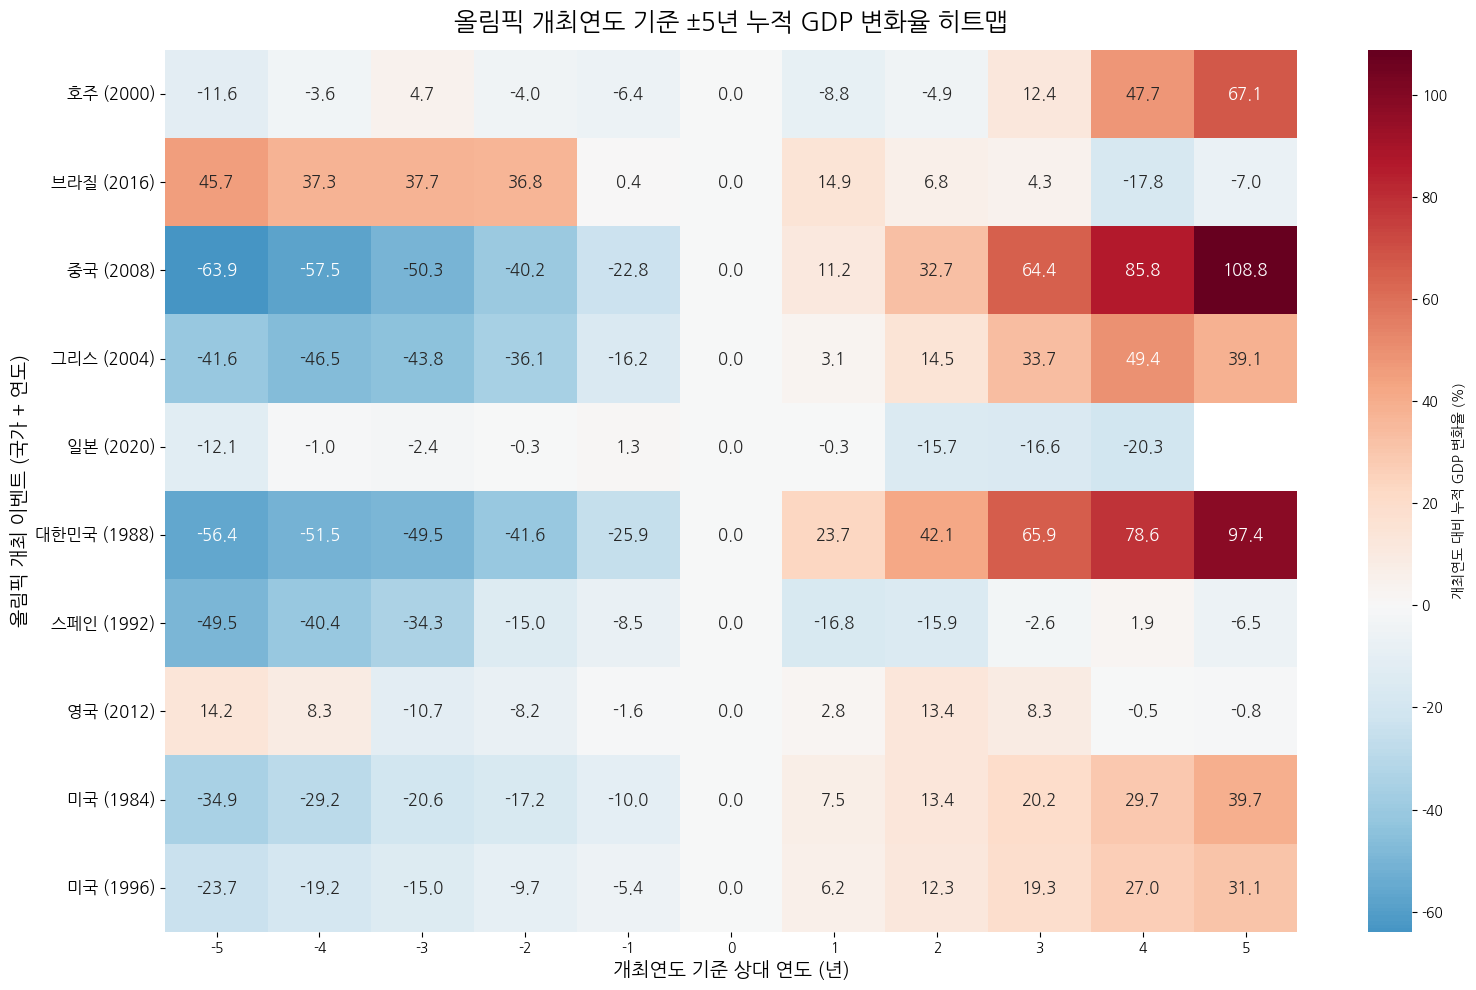

In [ ]:
country_ko_map = {
    'Australia': '호주',
    'Brazil': '브라질',
    'China': '중국',
    'Greece': '그리스',
    'Japan': '일본',
    'Korea, Rep.': '대한민국',
    'Spain': '스페인',
    'United Kingdom': '영국',
    'United States': '미국'
}

plt.figure(figsize=(16, 10))

ax = sns.heatmap(
    pivot_cum,
    cmap='RdBu_r',
    center=0,
    annot=True,
    fmt=".1f",
    annot_kws={"size": 12},
    cbar_kws={'label': '개최연도 대비 누적 GDP 변화율 (%)'}
)

plt.title('올림픽 개최연도 기준 ±5년 누적 GDP 변화율 히트맵', fontsize=18, pad=15)
plt.xlabel('개최연도 기준 상대 연도 (년)', fontsize=14)
plt.ylabel('올림픽 개최 이벤트 (국가 + 연도)', fontsize=14)

# y축 국가명 한글 변환
new_labels = []
for label in ax.get_yticklabels():
    text = label.get_text()
    country = text.rsplit(' (', 1)[0]
    year = text.rsplit(' (', 1)[1]
    country_ko = country_ko_map.get(country, country)
    new_labels.append(f"{country_ko} ({year}")

ax.set_yticklabels(new_labels, fontsize=12)

plt.tight_layout()
plt.show()
